# Big-Vul: Vulnerability Patterns and Machine Learning Analysis

## Objective

This project analyzes the Big-Vul C/C++ vulnerability dataset to understand
vulnerability patterns, severity, affected projects, and characteristics of
vulnerability-fixing code changes.

A machine-learning model is then trained to predict the coarse
`vulnerability_classification` category using vulnerability metadata and
repository/code-change characteristics.

## Research Questions

1. Which vulnerability categories and CWE types occur most frequently?
2. How are vulnerabilities distributed across projects and publication years?
3. Is vulnerability severity associated with the size of the corresponding code fix?
4. Can vulnerability metadata and code-change characteristics predict the
   coarse vulnerability classification?

## Research Direction

This project focuses on empirical software-engineering analysis rather than
building a large AI system. The results are intended to provide a reproducible
baseline for studying software vulnerabilities and AI-assisted software
engineering.

In [229]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# JSON parsing
import json

# Statistical analysis
from scipy.stats import spearmanr

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Dataset

The original Big-Vul CSV contains vulnerability metadata, CVE information,
repository information, commit information, and code-change information.

In [230]:
DATA_PATH = "../dataset/all_c_cpp_release2.0.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (4432, 22)


In [231]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4432
Columns: 22


In [232]:
df.head()

,Unnamed: 0,authentication_required,availability_impact,cve_id,cve_page,cwe_id,access_complexity,confidentiality_impact,integrity_impact,publish_date,score,summary,update_date,vulnerability_classification,ref_link,commit_id,commit_message,files_changed,lang,project,version_after_fix,version_before_fix
0,0,Not required,Partial,CVE-2009-1194,https://www.cvedetails.com/cve/CVE-2009-1194/,CWE-189,Medium,Partial,Partial,2009-05-11,6.8,Integer overflow in the pango_glyph_string_set_size function in pango/glyphstring.c in Pango before 1.24 allows cont...,2018-10-10,DoS Exec Code Overflow,https://github.com/bratsche/pango/commit/4de30e5500eaeb49f4bf0b7a07f718e149a2ed5e,4de30e5500eaeb49f4bf0b7a07f718e149a2ed5e,[glyphstring] Handle overflow with very long glyphstrings,"{""sha"": ""8fb70313eb8835dcce812a86209e2a7d88457795"", ""filename"": ""pango/glyphstring.c"", ""status"": ""modified"", ""additi...",C,pango,4de30e5500eaeb49f4bf0b7a07f718e149a2ed5e,1c9433bfe43890b102c8cead8ab3ee34b44c5c37
1,1,Not required,Partial,CVE-2010-2809,https://www.cvedetails.com/cve/CVE-2010-2809/,CWE-94,Medium,Partial,Partial,2010-08-19,6.8,The default configuration of the <Button2> binding in Uzbl before 2010.08.05 does not properly use the @SELECTED_URI...,2017-08-16,Exec Code,https://github.com/Dieterbe/uzbl/commit/9cc39cb5c9396be013b5dc2ba7e4b3eaa647e975,9cc39cb5c9396be013b5dc2ba7e4b3eaa647e975,Don't shell-interpret \@SELECTED_URI (fixes FS#240),"{""sha"": ""da2c583dc09acf7eb567df6c9c629e61f3c80fa3"", ""filename"": ""examples/config/config"", ""status"": ""modified"", ""add...",C,uzbl,9cc39cb5c9396be013b5dc2ba7e4b3eaa647e975,afc0f873e873839da75a54e8ca8095d335527786
2,2,Not required,Partial,CVE-2010-2060,https://www.cvedetails.com/cve/CVE-2010-2060/,NaN,Low,Partial,Partial,2010-06-07,7.5,The put command functionality in beanstalkd 1.4.5 and earlier allows remote attackers to execute arbitrary Beanstalk...,2017-08-16,Exec Code,https://github.com/kr/beanstalkd/commit/2e8e8c6387ecdf5923dfc4d7718d18eba1b0873d,2e8e8c6387ecdf5923dfc4d7718d18eba1b0873d,"Discard job body bytes if the job is too big.\n\nPreviously, a malicious user could craft a job payload and inject\n...","{""sha"": ""bcfb7d4b22c28d3f909d13dad54b4caa1284fdbe"", ""filename"": ""check-one.sh"", ""status"": ""modified"", ""additions"": 1...",C,beanstalkd,2e8e8c6387ecdf5923dfc4d7718d18eba1b0873d,62328a506b8ed24e52c264f073ecbf4e9254f861
3,3,Not required,Partial,CVE-2010-1155,https://www.cvedetails.com/cve/CVE-2010-1155/,CWE-20,Medium,Partial,Partial,2010-04-16,6.8,"Irssi before 0.8.15, when SSL is used, does not verify that the server hostname matches a domain name in the subject...",2017-08-16,NaN,https://github.com/ensc/irssi-proxy/commit/85bbc05b21678e80423815d2ef1dfe26208491ab,85bbc05b21678e80423815d2ef1dfe26208491ab,Check if an SSL certificate matches the hostname of the server we are connecting to\n\ngit-svn-id: http://svn.irssi....,"{""sha"": ""5a9c9bc71553d37a17b89654bec0b6e98b5679b9"", ""filename"": ""src/core/network-openssl.c"", ""status"": ""modified"", ...",C,irssi-proxy,85bbc05b21678e80423815d2ef1dfe26208491ab,d5688da48306918cdfd79ee9b27abe377204befb
4,4,Not required,Partial,CVE-2010-1152,https://www.cvedetails.com/cve/CVE-2010-1152/,CWE-20,Low,NaN,NaN,2010-04-12,5.0,memcached.c in memcached before 1.4.3 allows remote attackers to cause a denial of service (daemon hang or crash) vi...,2011-03-01,DoS,https://github.com/memcached/memcached/commit/d9cd01ede97f4145af9781d448c62a3318952719,d9cd01ede97f4145af9781d448c62a3318952719,Use strncmp when checking for large ascii multigets.,"{""sha"": ""3e2e9c59e274910dd88af6fbb73006279b5a6016"", ""filename"": ""memcached.c"", ""status"": ""modified"", ""additions"": 3,...",C,memcached,d9cd01ede97f4145af9781d448c62a3318952719,ea0fec7989ba00cf68326d017fd801a1716f8855


In [233]:
df.columns.tolist()

['Unnamed: 0',
 'authentication_required',
 'availability_impact',
 'cve_id',
 'cve_page',
 'cwe_id',
 'access_complexity',
 'confidentiality_impact',
 'integrity_impact',
 'publish_date',
 'score',
 'summary',
 'update_date',
 'vulnerability_classification',
 'ref_link',
 'commit_id',
 'commit_message',
 'files_changed',
 'lang',
 'project',
 'version_after_fix',
 'version_before_fix']

In [234]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4432 entries, 0 to 4431
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    4432 non-null   int64  
 1   authentication_required       4114 non-null   str    
 2   availability_impact           3327 non-null   str    
 3   cve_id                        4126 non-null   str    
 4   cve_page                      4114 non-null   str    
 5   cwe_id                        3693 non-null   str    
 6   access_complexity             4114 non-null   str    
 7   confidentiality_impact        2587 non-null   str    
 8   integrity_impact              2474 non-null   str    
 9   publish_date                  4114 non-null   str    
 10  score                         4114 non-null   float64
 11  summary                       4114 non-null   str    
 12  update_date                   4432 non-null   str    
 13  vulnerability_

In [235]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,4432.0,NaN,NaN,NaN,2215.5,1279.552526,0.0,1107.75,2215.5,3323.25,4431.0
authentication_required,4114,3,Not required,3993,NaN,NaN,NaN,NaN,NaN,NaN,NaN
availability_impact,3327,3,Partial,2206,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cve_id,4126,3754,CVE-2012-2875,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cve_page,4114,3742,https://www.cvedetails.com/cve/CVE-2012-2875/,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cwe_id,3693,91,CWE-119,694,NaN,NaN,NaN,NaN,NaN,NaN,NaN
access_complexity,4114,4,Low,2170,NaN,NaN,NaN,NaN,NaN,NaN,NaN
confidentiality_impact,2587,3,Partial,1856,NaN,NaN,NaN,NaN,NaN,NaN,NaN
integrity_impact,2474,3,Partial,1799,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publish_date,4114,837,2017-09-14,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [236]:
clean_df = df.copy()

print("Working copy created.")

Working copy created.


In [237]:
if "Unnamed: 0" in clean_df.columns:
    clean_df = clean_df.drop(columns=["Unnamed: 0"])

print("Shape after removing index:", clean_df.shape)

Shape after removing index: (4432, 21)


In [238]:
problem_columns = [
    "authentication_required",
    "availability_impact",
    "access_complexity",
    "confidentiality_impact",
    "integrity_impact"
]

for col in problem_columns:
    clean_df[col] = clean_df[col].replace("???", np.nan)

print("Converted '???' values to NaN.")

Converted '???' values to NaN.


In [239]:
for col in problem_columns:
    print(
        f"{col}: {clean_df[col].isna().sum()} missing values"
    )

authentication_required: 358 missing values
availability_impact: 1145 missing values
access_complexity: 358 missing values
confidentiality_impact: 1885 missing values
integrity_impact: 1998 missing values


In [240]:
invalid_rows = clean_df["commit_id"].eq("#F0")

print("Invalid commit rows:", invalid_rows.sum())

Invalid commit rows: 2


In [241]:
clean_df = clean_df.loc[~invalid_rows].copy()

print("Shape after removing invalid commits:", clean_df.shape)

Shape after removing invalid commits: (4430, 21)


In [242]:
clean_df["score"] = pd.to_numeric(
    clean_df["score"],
    errors="coerce"
)

clean_df["score"].describe()

count    4112.000000
mean        5.952262
std         1.927067
min         0.000000
25%         4.300000
50%         6.600000
75%         7.500000
max        10.000000
Name: score, dtype: float64

In [243]:
clean_df["publish_date"] = pd.to_datetime(
    clean_df["publish_date"],
    errors="coerce"
)

clean_df["update_date"] = pd.to_datetime(
    clean_df["update_date"],
    errors="coerce"
)

clean_df["publish_year"] = clean_df["publish_date"].dt.year

def parse_files_changed(value):
    """
    Convert the JSON string in files_changed
    into a Python dictionary.
    """
    try:
        return json.loads(value)
    except (TypeError, json.JSONDecodeError):
        return None

clean_df["files_changed_parsed"] = (
    clean_df["files_changed"]
    .apply(parse_files_changed)
)

In [244]:
clean_df["files_changed_parsed"].head()

0    {'sha': '8fb70313eb8835dcce812a86209e2a7d88457795', 'filename': 'pango/glyphstring.c', 'status': 'modified', 'additi...
1    {'sha': 'da2c583dc09acf7eb567df6c9c629e61f3c80fa3', 'filename': 'examples/config/config', 'status': 'modified', 'add...
2                                                                                                                       None
3                                                                                                                       None
4    {'sha': '3e2e9c59e274910dd88af6fbb73006279b5a6016', 'filename': 'memcached.c', 'status': 'modified', 'additions': 3,...
Name: files_changed_parsed, dtype: object

In [245]:
def extract_patch_info(value):
    """
    Extract useful fields from the files_changed JSON object.
    """
    if not isinstance(value, dict):
        return pd.Series({
            "filename": np.nan,
            "additions": np.nan,
            "deletions": np.nan,
            "patch": np.nan
        })

    return pd.Series({
        "filename": value.get("filename"),
        "additions": value.get("additions"),
        "deletions": value.get("deletions"),
        "patch": value.get("patch")
    })

patch_info = clean_df["files_changed_parsed"].apply(
    extract_patch_info
)

clean_df = pd.concat(
    [clean_df, patch_info],
    axis=1
)

In [246]:
# Drop duplicate columns, keeping the first instance
clean_df = clean_df.loc[:, ~clean_df.columns.duplicated(keep='first')]

# Now your original transformation will execute cleanly
clean_df["additions"] = pd.to_numeric(clean_df["additions"], errors="coerce")
clean_df["deletions"] = pd.to_numeric(clean_df["deletions"], errors="coerce")

clean_df["lines_changed"] = (
    clean_df["additions"].fillna(0) + clean_df["deletions"].fillna(0)
)

In [247]:
missing_report = pd.DataFrame({
    "missing_count": clean_df.isna().sum(),
    "missing_percent": (
        clean_df.isna().mean() * 100
    )
}).sort_values(
    "missing_percent",
    ascending=False
)

missing_report.head(15)

,missing_count,missing_percent
deletions,2338,52.776524
additions,2338,52.776524
patch,2093,47.246050
filename,2092,47.223476
files_changed_parsed,2092,47.223476
integrity_impact,1997,45.079007
confidentiality_impact,1884,42.528217
vulnerability_classification,1319,29.774266
availability_impact,1145,25.846501
cwe_id,739,16.681716


## 6. Vulnerability Analysis

This section examines the distribution of vulnerability categories,
CWE weaknesses, affected projects, and publication periods.

In [248]:
cwe_counts = clean_df["cwe_id"].value_counts()

print("Unique CWE categories:", clean_df["cwe_id"].nunique())
cwe_counts.head(15)

Unique CWE categories: 91


cwe_id
CWE-119    694
CWE-20     445
CWE-125    365
CWE-200    272
CWE-264    266
CWE-399    265
CWE-416    184
CWE-189    133
CWE-476    132
CWE-190    108
CWE-362     99
CWE-787     72
CWE-284     68
CWE-79      44
CWE-254     34
Name: count, dtype: int64

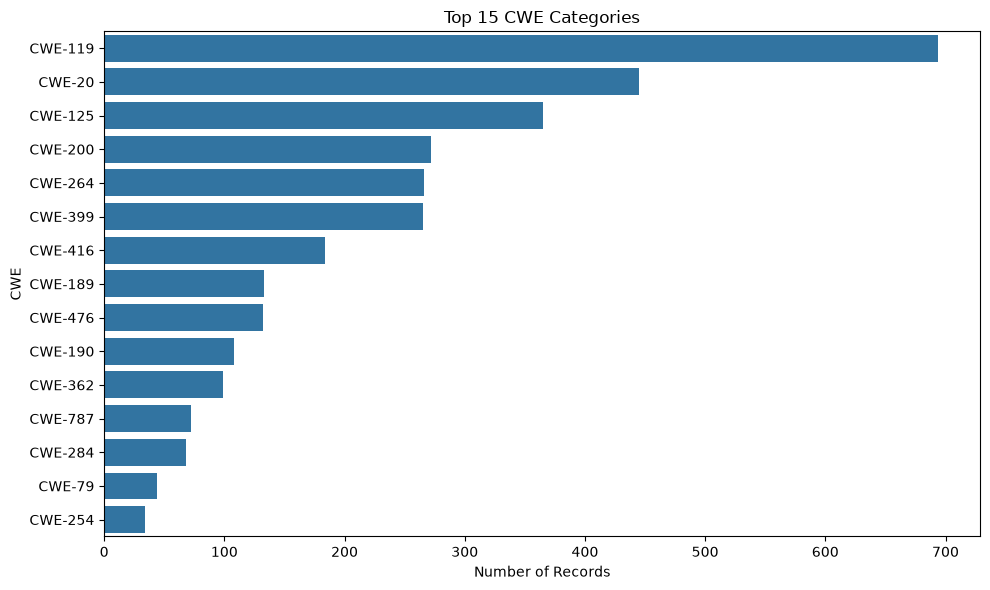

In [249]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=cwe_counts.head(15).values,
    y=cwe_counts.head(15).index
)

plt.title("Top 15 CWE Categories")
plt.xlabel("Number of Records")
plt.ylabel("CWE")

plt.tight_layout()
plt.show()

### Finding

The dataset contains a highly uneven distribution of CWE categories.
A small number of CWE types account for a substantial portion of the
observed vulnerability records, while many categories occur relatively
infrequently.

In [250]:
classification_counts = (
    clean_df["vulnerability_classification"]
    .value_counts()
)

classification_counts

vulnerability_classification
DoS                                     1159
DoS Overflow                             380
+Info                                    306
Overflow                                 229
Bypass                                   204
+Priv                                    130
Exec Code                                 96
Exec Code Overflow                        69
DoS Overflow Mem. Corr.                   66
DoS Exec Code Overflow                    53
DoS Exec Code Overflow Mem. Corr.         45
DoS +Priv                                 40
XSS                                       39
Overflow +Priv                            31
DoS Exec Code                             26
DoS +Info                                 24
Bypass +Info                              23
DoS Mem. Corr.                            22
Dir. Trav.                                22
Exec Code Overflow Mem. Corr.             20
Overflow Mem. Corr.                       16
DoS Overflow +Priv        

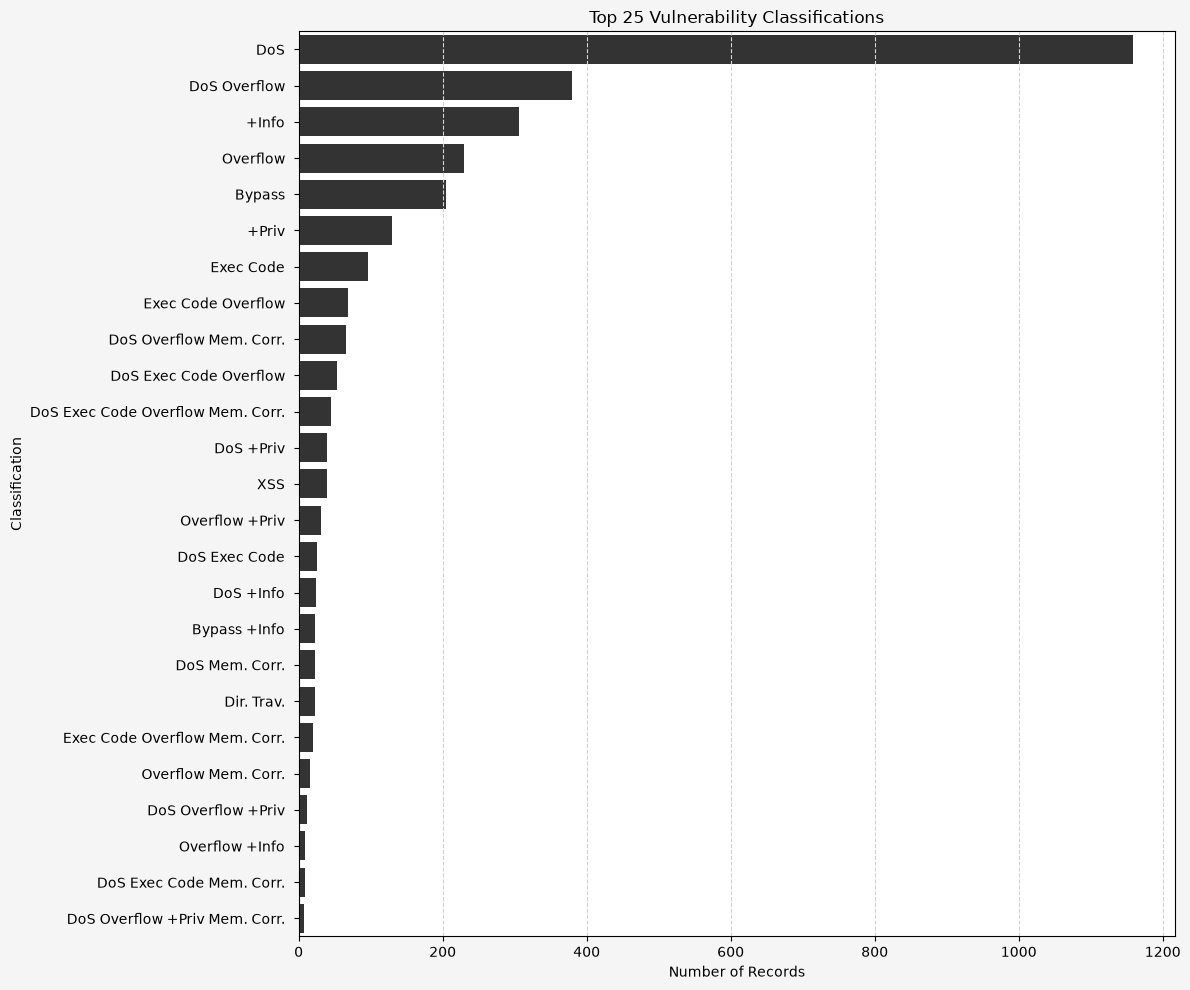

In [251]:
top_counts = classification_counts.head(25)

plt.figure(figsize=(12, 10), facecolor='#f5f5f5')

sns.barplot(
    x=top_counts.values,
    y=top_counts.index,
    color='#333333'
)

plt.title("Top 25 Vulnerability Classifications")
plt.xlabel("Number of Records")
plt.ylabel("Classification")

plt.grid(axis='x', color='#d3d3d3', linestyle='--')
plt.tight_layout()
plt.show()

In [252]:
year_counts = (
    clean_df["publish_year"]
    .value_counts()
    .sort_index()
)

year_counts

publish_year
2009.0       1
2010.0       6
2011.0     116
2012.0     290
2013.0     376
2014.0     260
2015.0     296
2016.0     694
2017.0    1013
2018.0     570
2019.0     490
Name: count, dtype: int64

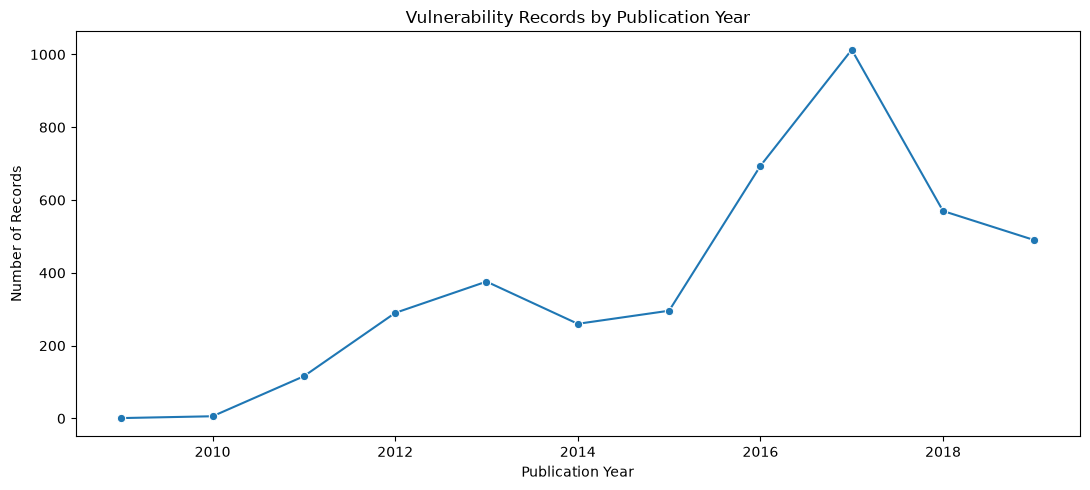

In [253]:
plt.figure(figsize=(11, 5))

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values,
    marker="o"
)

plt.title("Vulnerability Records by Publication Year")
plt.xlabel("Publication Year")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [254]:
clean_df["score"].describe()

count    4112.000000
mean        5.952262
std         1.927067
min         0.000000
25%         4.300000
50%         6.600000
75%         7.500000
max        10.000000
Name: score, dtype: float64

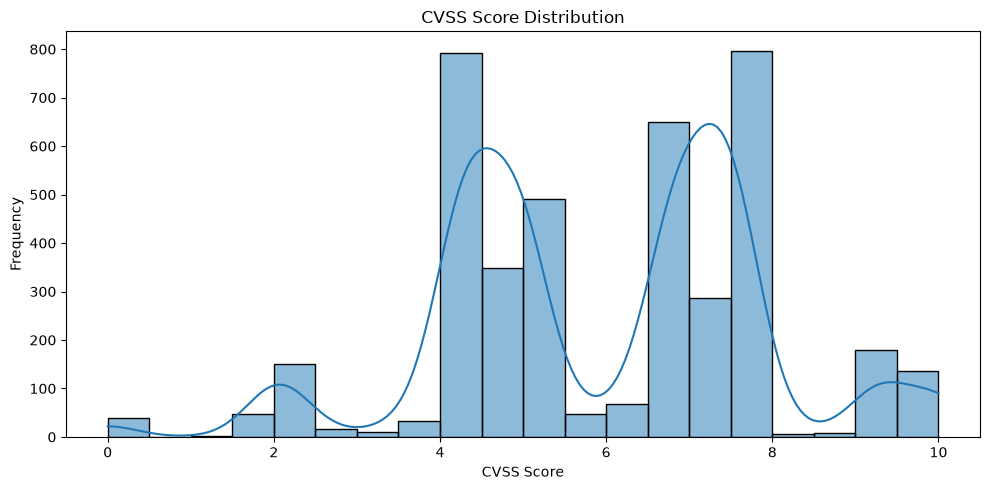

In [255]:
plt.figure(figsize=(10, 5))

sns.histplot(
    clean_df["score"].dropna(),
    bins=20,
    kde=True
)

plt.title("CVSS Score Distribution")
plt.xlabel("CVSS Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [256]:
top_classes = (
    clean_df[
        "vulnerability_classification"
    ]
    .value_counts()
    .head(10)
    .index
)

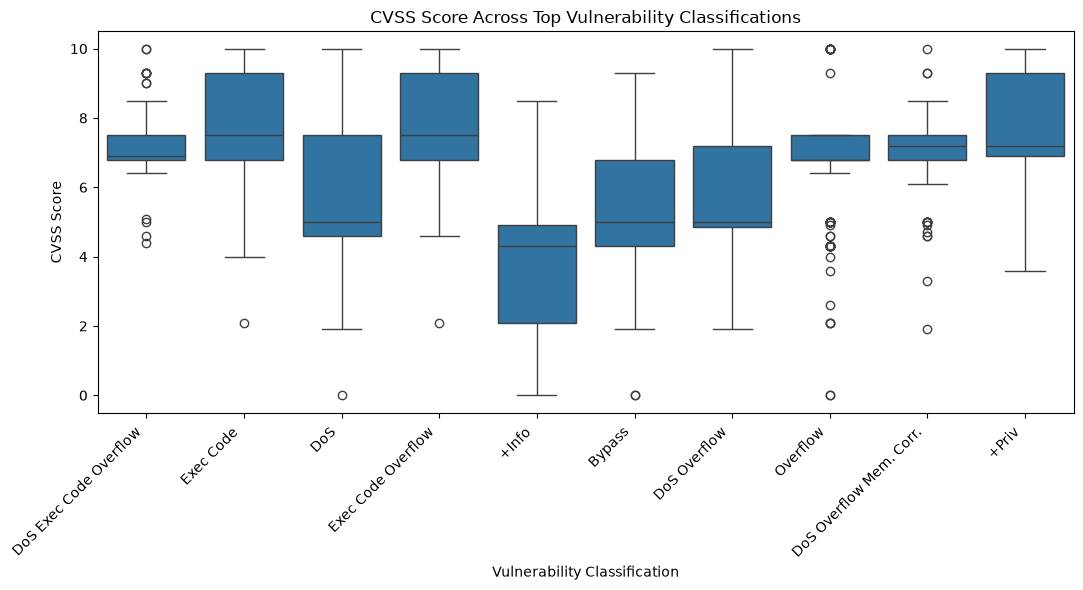

In [257]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=clean_df[
        clean_df["vulnerability_classification"].isin(top_classes)
    ],
    x="vulnerability_classification",
    y="score"
)

plt.title("CVSS Score Across Top Vulnerability Classifications")
plt.xlabel("Vulnerability Classification")
plt.ylabel("CVSS Score")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [258]:
for col in [
    "access_complexity",
    "authentication_required",
    "confidentiality_impact",
    "integrity_impact",
    "availability_impact"
]:
    print("\n", col)
    print(
        clean_df.groupby(
            col,
            dropna=False
        )["score"].agg(
            ["count", "mean", "median"]
        )
    )


 access_complexity
                   count      mean  median
access_complexity                         
High                 105  5.060000     5.1
Low                 2169  6.251406     7.2
Medium              1798  5.775918     5.8
NaN                   40  0.000000     0.0

 authentication_required
                         count      mean  median
authentication_required                         
Not required              3991  6.033425     6.8
Single system               81  4.892593     4.0
NaN                         40  0.000000     0.0

 confidentiality_impact
                        count      mean  median
confidentiality_impact                         
Complete                  690  8.101449     7.2
Partial                  1856  6.287123     6.8
NaN                      1566  4.608429     4.6

 integrity_impact
                  count      mean  median
integrity_impact                         
Complete            634  8.338013     8.3
Partial            1799  6.411784     6.8

In [259]:
project_counts = (
    clean_df["project"]
    .value_counts()
)

project_counts.head(15)

project
Chrome          1518
linux            927
Android          374
ImageMagick      189
tcpdump          122
FFmpeg            84
php-src           66
radare2           50
krb5              38
file              29
ImageMagick6      29
hhvm              25
openssl           25
openjpeg          25
libarchive        24
Name: count, dtype: int64

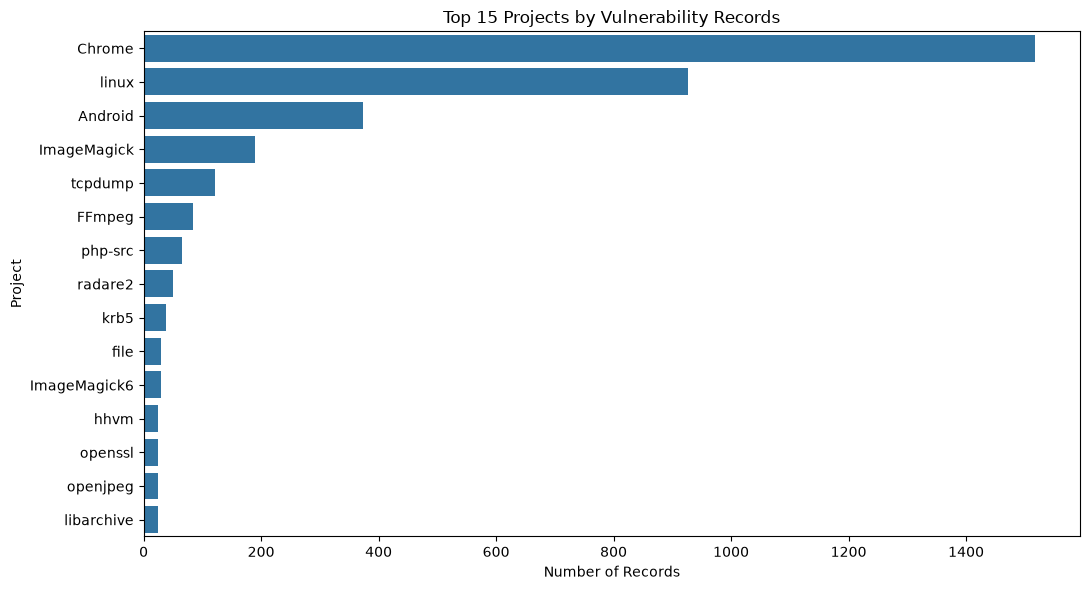

In [260]:
plt.figure(figsize=(11, 6))

sns.barplot(
    x=project_counts.head(15).values,
    y=project_counts.head(15).index
)

plt.title("Top 15 Projects by Vulnerability Records")
plt.xlabel("Number of Records")
plt.ylabel("Project")

plt.tight_layout()
plt.show()

In [261]:
project_summary = (
    clean_df
    .groupby("project")
    .agg(
        records=("cve_id", "count"),
        unique_cves=("cve_id", "nunique"),
        mean_cvss=("score", "mean"),
        mean_patch_size=("lines_changed", "mean")
    )
    .sort_values(
        "records",
        ascending=False
    )
)

project_summary.head(15)

,records,unique_cves,mean_cvss,mean_patch_size
project,,,,
Chrome,1212,1133,6.207583,4.137681
linux,927,869,5.338188,11.052859
Android,374,312,7.532620,0.000000
ImageMagick,189,154,5.360847,8.767196
tcpdump,122,110,7.336066,0.704918
FFmpeg,84,78,6.150000,8.119048
php-src,66,61,6.524242,8.348485
radare2,50,46,5.114000,11.640000
krb5,38,35,5.486842,9.526316


In [262]:
clean_df["lines_changed"].describe()

count    4430.000000
mean        6.711738
std        22.736362
min         0.000000
25%         0.000000
50%         0.000000
75%         5.000000
max       480.000000
Name: lines_changed, dtype: float64

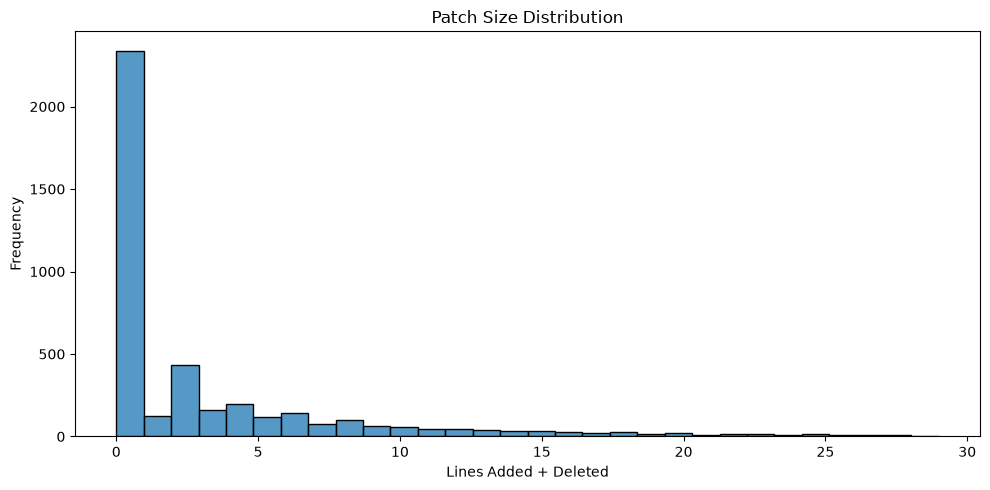

In [263]:
plt.figure(figsize=(10, 5))

upper_limit = clean_df["lines_changed"].quantile(0.95)

sns.histplot(
    clean_df[
        clean_df["lines_changed"] <= upper_limit
    ]["lines_changed"],
    bins=30
)

plt.title("Patch Size Distribution")
plt.xlabel("Lines Added + Deleted")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

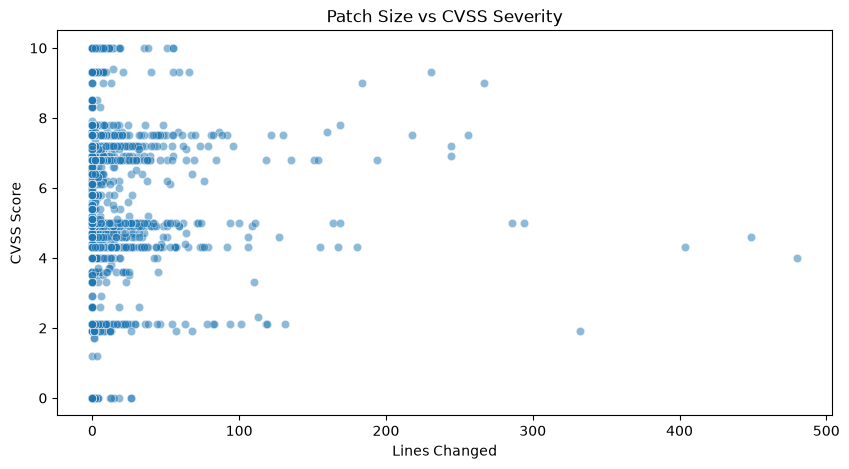

In [264]:
plt.figure(figsize=(10, 5))

plot_df = clean_df[
    ["lines_changed", "score"]
].dropna()

sns.scatterplot(
    data=plot_df,
    x="lines_changed",
    y="score",
    alpha=0.5
)

plt.title("Patch Size vs CVSS Severity")
plt.xlabel("Lines Changed")
plt.ylabel("CVSS Score")

plt.show()

In [265]:
rho, p_value = spearmanr(
    plot_df["lines_changed"],
    plot_df["score"]
)

print(f"Spearman correlation: {rho:.4f}")
print(f"P-value: {p_value:.6f}")

Spearman correlation: -0.1436
P-value: 0.000000


### Finding

A weak/moderate/strong relationship was observed between patch size
and CVSS severity based on the Spearman correlation.

The result should be interpreted as an association rather than evidence
that larger patches cause more severe vulnerabilities.

In [266]:
from collections import Counter
import re

messages = (
    clean_df["commit_message"]
    .dropna()
    .astype(str)
)

words = []

for message in messages:
    tokens = re.findall(
        r"\b[a-zA-Z]{3,}\b",
        message.lower()
    )
    words.extend(tokens)

word_counts = Counter(words)

word_counts.most_common(20)

[('the', 10891),
 ('org', 4863),
 ('chromium', 4686),
 ('com', 3553),
 ('and', 3122),
 ('this', 2645),
 ('for', 2507),
 ('bug', 2434),
 ('off', 2129),
 ('svn', 2073),
 ('signed', 2066),
 ('https', 1958),
 ('commit', 1924),
 ('that', 1878),
 ('fix', 1803),
 ('reviewed', 1797),
 ('review', 1455),
 ('not', 1407),
 ('with', 1396),
 ('from', 1295)]

## 10. Feature Engineering

Features are selected to represent three perspectives:

1. Vulnerability severity and impact
2. Repository characteristics
3. Code-change characteristics

The target is the coarse `vulnerability_classification` category.

In [267]:
model_df = clean_df.copy()

In [268]:
features = [
    "score",
    "access_complexity",
    "authentication_required",
    "confidentiality_impact",
    "integrity_impact",
    "availability_impact",
    "project",
    "lang",
    "lines_changed"
]

target = "vulnerability_classification"

In [269]:
class_counts = (
    model_df[target]
    .value_counts()
)

class_counts

vulnerability_classification
DoS                                     1159
DoS Overflow                             380
+Info                                    306
Overflow                                 229
Bypass                                   204
+Priv                                    130
Exec Code                                 96
Exec Code Overflow                        69
DoS Overflow Mem. Corr.                   66
DoS Exec Code Overflow                    53
DoS Exec Code Overflow Mem. Corr.         45
DoS +Priv                                 40
XSS                                       39
Overflow +Priv                            31
DoS Exec Code                             26
DoS +Info                                 24
Bypass +Info                              23
DoS Mem. Corr.                            22
Dir. Trav.                                22
Exec Code Overflow Mem. Corr.             20
Overflow Mem. Corr.                       16
DoS Overflow +Priv        

In [270]:
MIN_CLASS_COUNT = 20

rare_classes = class_counts[
    class_counts < MIN_CLASS_COUNT
].index

model_df["target"] = (
    model_df[target]
    .where(
        ~model_df[target].isin(rare_classes),
        "Other"
    )
)

model_df["target"].value_counts()

target
DoS                                   1159
DoS Overflow                           380
+Info                                  306
Overflow                               229
Bypass                                 204
+Priv                                  130
Other                                  127
Exec Code                               96
Exec Code Overflow                      69
DoS Overflow Mem. Corr.                 66
DoS Exec Code Overflow                  53
DoS Exec Code Overflow Mem. Corr.       45
DoS +Priv                               40
XSS                                     39
Overflow +Priv                          31
DoS Exec Code                           26
DoS +Info                               24
Bypass +Info                            23
DoS Mem. Corr.                          22
Dir. Trav.                              22
Exec Code Overflow Mem. Corr.           20
Name: count, dtype: int64

In [271]:
X = model_df[features].copy()
y = model_df["target"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("NaN values in y:", y.isna().sum())
print(y[y.isna()].head())
print(y.value_counts(dropna=False))

# Remove samples where the target is NaN before stratified splitting.
mask = y.notna()
X_clean = X.loc[mask]
y_clean = y.loc[mask]

print("Clean feature shape:", X_clean.shape)
print("Clean target shape:", y_clean.shape)

X shape: (4430, 9)
y shape: (4430,)
NaN values in y: 1319
3     NaN
7     NaN
16    NaN
17    NaN
28    NaN
Name: target, dtype: str
target
NaN                                   1319
DoS                                   1159
DoS Overflow                           380
+Info                                  306
Overflow                               229
Bypass                                 204
+Priv                                  130
Other                                  127
Exec Code                               96
Exec Code Overflow                      69
DoS Overflow Mem. Corr.                 66
DoS Exec Code Overflow                  53
DoS Exec Code Overflow Mem. Corr.       45
DoS +Priv                               40
XSS                                     39
Overflow +Priv                          31
DoS Exec Code                           26
DoS +Info                               24
Bypass +Info                            23
DoS Mem. Corr.                          22


In [272]:
X = model_df[features].copy()
y = model_df["target"].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (4430, 9)
Target shape: (4430,)


In [273]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.30,
    random_state=42,
    stratify=y_clean
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2177
Testing samples: 934


In [274]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values in y:")
print(y.isna().sum())

print("\nTarget distribution:")
print(y.value_counts(dropna=False))

X shape: (4430, 9)
y shape: (4430,)

Missing values in y:
1319

Target distribution:
target
NaN                                   1319
DoS                                   1159
DoS Overflow                           380
+Info                                  306
Overflow                               229
Bypass                                 204
+Priv                                  130
Other                                  127
Exec Code                               96
Exec Code Overflow                      69
DoS Overflow Mem. Corr.                 66
DoS Exec Code Overflow                  53
DoS Exec Code Overflow Mem. Corr.       45
DoS +Priv                               40
XSS                                     39
Overflow +Priv                          31
DoS Exec Code                           26
DoS +Info                               24
Bypass +Info                            23
DoS Mem. Corr.                          22
Dir. Trav.                              22
Exec 

In [275]:
numeric_features = [
    "score",
    "lines_changed"
]

In [276]:
categorical_features = [
    "access_complexity",
    "authentication_required",
    "confidentiality_impact",
    "integrity_impact",
    "availability_impact",
    "project",
    "lang"
]

In [277]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [278]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [279]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [280]:
model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )
])

In [281]:
model.fit(
    X_train,
    y_train
)

print("Model training completed.")

Model training completed.


In [282]:
y_pred = model.predict(X_test)

In [283]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.2077


In [284]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

                                    precision    recall  f1-score   support

                            +Info        0.53      0.38      0.44        92
                            +Priv        0.50      0.15      0.24        39
                           Bypass        0.12      0.18      0.14        61
                     Bypass +Info        0.11      0.43      0.18         7
                       Dir. Trav.        0.03      0.43      0.05         7
                              DoS        0.77      0.16      0.27       348
                        DoS +Info        0.08      0.57      0.14         7
                        DoS +Priv        0.14      0.75      0.24        12
                    DoS Exec Code        0.04      0.12      0.06         8
           DoS Exec Code Overflow        0.00      0.00      0.00        16
DoS Exec Code Overflow Mem. Corr.        0.27      0.69      0.39        13
                   DoS Mem. Corr.        0.00      0.00      0.00         6
           

In [285]:
macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

Macro F1: 0.1699
Weighted F1: 0.2223


In [286]:
labels = model.named_steps[
    "classifier"
].classes_

In [287]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

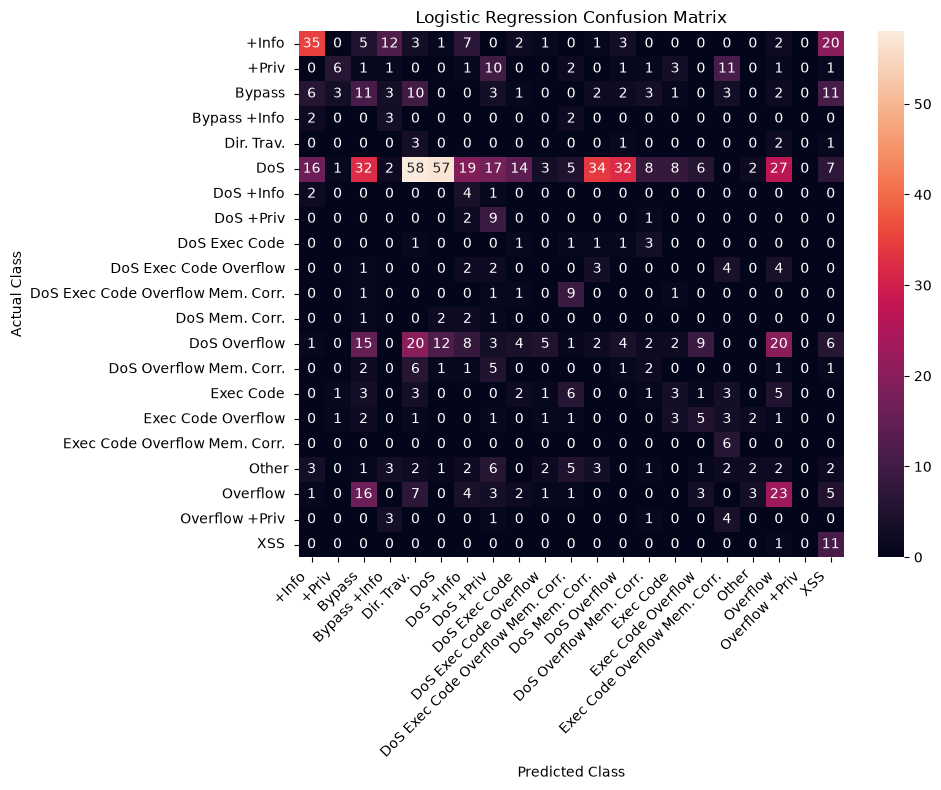

In [288]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [289]:
feature_names = (
    model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [290]:
coefficients = (
    model
    .named_steps["classifier"]
    .coef_
)

In [291]:
coef_df = pd.DataFrame(
    coefficients,
    columns=feature_names,
    index=model
        .named_steps["classifier"]
        .classes_
)

coef_df

,numeric__score,numeric__lines_changed,categorical__access_complexity_High,categorical__access_complexity_Low,categorical__access_complexity_Medium,categorical__authentication_required_Not required,categorical__authentication_required_Single system,categorical__confidentiality_impact_Complete,categorical__confidentiality_impact_Partial,categorical__integrity_impact_Complete,categorical__integrity_impact_Partial,categorical__availability_impact_Complete,categorical__availability_impact_Partial,categorical__project_AFFLIBv3,categorical__project_Android,categorical__project_ArduinoJson,categorical__project_Bento4,categorical__project_CImg,categorical__project_Chrome,categorical__project_Espruino,categorical__project_FFmpeg,categorical__project_FreeRDP,categorical__project_ImageMagick,categorical__project_ImageMagick6,categorical__project_JPEGsnoop,categorical__project_Jaxer,categorical__project_LibRaw,categorical__project_LibRaw-demosaic-pack-GPL2,categorical__project_Little-CMS,categorical__project_MAC-Telnet,categorical__project_ModSecurity,categorical__project_OpenSC,categorical__project_Sigil,categorical__project_Varnish-Cache,categorical__project_VeraCrypt,categorical__project_WAVM,categorical__project_WavPack,categorical__project_ZRTPCPP,categorical__project_abrt,categorical__project_acpica,categorical__project_aircrack-ng,categorical__project_android_security,categorical__project_appweb,categorical__project_audiofile,categorical__project_bdwgc,categorical__project_beanstalkd,categorical__project_bitlbee,categorical__project_bro,categorical__project_bubblewrap,categorical__project_capnproto,categorical__project_ceph,categorical__project_cgminer,categorical__project_civetweb,categorical__project_clamav-devel,categorical__project_collectd,categorical__project_corosync,categorical__project_cryptopp,categorical__project_cups,categorical__project_curl,categorical__project_cyrus-imapd,categorical__project_domoticz,categorical__project_doxygen,categorical__project_electron,categorical__project_ettercap,categorical__project_exim,categorical__project_exiv2,categorical__project_ext-http,categorical__project_faad2,categorical__project_fbthrift,categorical__project_file,categorical__project_firejail,categorical__project_flex,categorical__project_fmt,categorical__project_folly,categorical__project_fontforge,categorical__project_frr,categorical__project_git,categorical__project_gnome-shell,categorical__project_gnulib,categorical__project_goahead,categorical__project_gpac,categorical__project_graphite,categorical__project_graphviz,categorical__project_gst-plugins-ugly,categorical__project_harfbuzz,categorical__project_hhvm,categorical__project_httpd,categorical__project_icu,categorical__project_illumos-gate,categorical__project_imageworsener,categorical__project_inspircd,categorical__project_iperf,categorical__project_irssi,categorical__project_jansson,categorical__project_jasper,categorical__project_jq,categorical__project_json-c,categorical__project_kamailio,categorical__project_keepalived,categorical__project_knc,categorical__project_krb5,categorical__project_kvm-guest-drivers-windows,categorical__project_leptonica,categorical__project_lhasa,categorical__project_libarchive,categorical__project_libass,categorical__project_libcomps,categorical__project_libebml,categorical__project_libevent,categorical__project_libfep,categorical__project_libgd,categorical__project_libgit2,categorical__project_libimobiledevice,categorical__project_libjpeg-turbo,categorical__project_libmatroska,categorical__project_libming,categorical__project_libmspack,categorical__project_libndp,categorical__project_libofx,categorical__project_libpcap,categorical__project_libplist,categorical__project_libpng,categorical__project_libreport,categorical__project_libreswan,categorical__project_libsndfile,categorical__project_libtiff,categorical__project_libu2f-host,categorical__project_libvips,categorical__project_libxkbcommon,categorical__project_libxml2,categorical__projec

In [292]:
for class_name in coef_df.index:

    class_coefficients = (
        coef_df
        .loc[class_name]
        .sort_values(
            ascending=False
        )
        .head(10)
    )

    print(
        f"\nTop positive features for: {class_name}"
    )

    print(class_coefficients)


Top positive features for: +Info 
categorical__confidentiality_impact_Complete    1.598519
categorical__integrity_impact_Partial           1.183965
categorical__project_Android                    1.177816
categorical__project_linux                      0.816897
categorical__project_Chrome                     0.767315
categorical__project_tor                        0.737421
categorical__availability_impact_Partial        0.702572
categorical__project_ImageMagick                0.680729
categorical__project_abrt                       0.656551
categorical__project_src                        0.633387
Name: +Info , dtype: float64

Top positive features for: +Priv 
categorical__project_server               1.506022
categorical__project_Android              1.335954
categorical__project_libfep               1.083046
categorical__project_sddm                 0.983744
categorical__integrity_impact_Complete    0.929927
categorical__project_passenger            0.890438
categorical__project_lxcf

In [293]:
mean_abs_coef = (
    coef_df.abs()
    .mean(axis=0)
    .sort_values(ascending=False)
    .head(15)
)

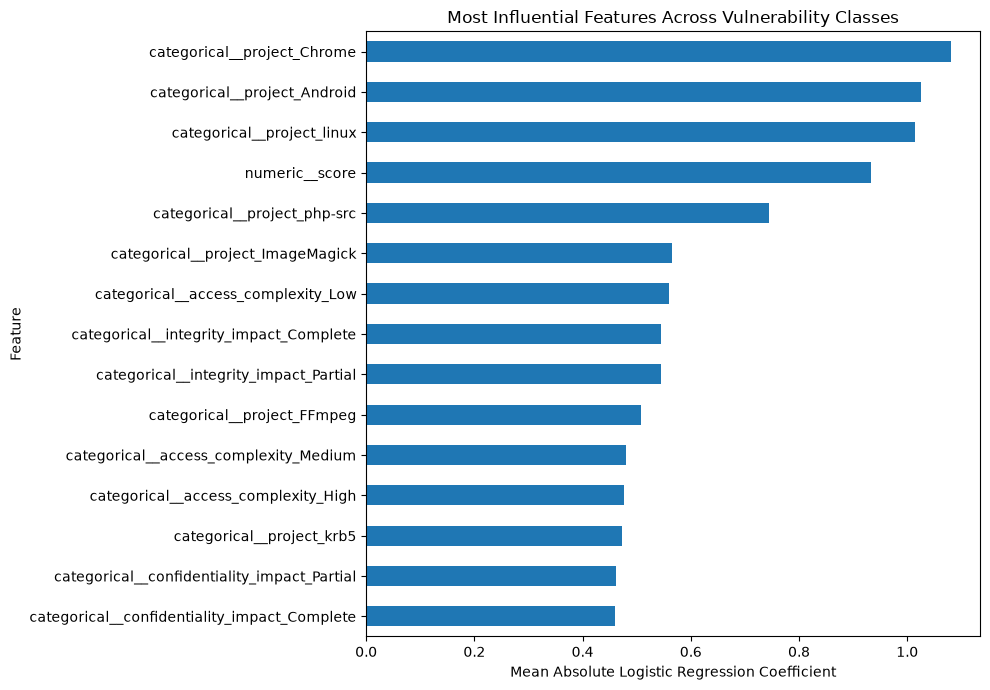

In [294]:
plt.figure(figsize=(10, 7))

mean_abs_coef.sort_values().plot(
    kind="barh"
)

plt.title(
    "Most Influential Features Across Vulnerability Classes"
)

plt.xlabel(
    "Mean Absolute Logistic Regression Coefficient"
)

plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [295]:
error_df = X_test.copy()

error_df["actual"] = y_test.values
error_df["predicted"] = y_pred

errors = error_df[
    error_df["actual"] != error_df["predicted"]
]

print("Misclassified samples:", len(errors))

errors.head(20)

Misclassified samples: 740


,score,access_complexity,authentication_required,confidentiality_impact,integrity_impact,availability_impact,project,lang,lines_changed,actual,predicted
2648,2.1,Low,Not required,Partial,NaN,NaN,Android,C,0.0,+Info,Bypass +Info
3408,6.8,Medium,Not required,Partial,Partial,Partial,Chrome,C,0.0,DoS,Bypass
1531,4.3,Medium,Not required,NaN,NaN,Partial,jasper,C,0.0,DoS,DoS Exec Code
505,7.5,Low,Not required,Partial,Partial,Partial,bootstrap-dht,C++,10.0,Exec Code,Overflow
550,4.6,Low,Not required,Partial,Partial,Partial,linux,C,4.0,+Info,DoS +Info
3824,4.3,Medium,Not required,NaN,NaN,Partial,Chrome,C,0.0,DoS,XSS
1542,4.3,Medium,Not required,NaN,NaN,Partial,jasper,C,0.0,DoS,DoS Exec Code
2329,5.0,Low,Not required,NaN,NaN,Partial,file,C,0.0,DoS,DoS Overflow
2911,2.1,Low,Not required,Partial,NaN,NaN,Android,C,0.0,Other,Bypass +Info
957,5.0,Low,Not required,NaN,NaN,Partial,opencv,C++,2.0,Overflow,Dir. Trav.


In [296]:
errors["actual"].value_counts()
errors["predicted"].value_counts()

predicted
Dir. Trav.                            111
Bypass                                 80
Overflow                               68
XSS                                    54
DoS +Priv                              54
DoS +Info                              48
DoS Mem. Corr.                         46
DoS Overflow                           41
+Info                                  31
Exec Code Overflow Mem. Corr.          30
DoS Exec Code                          26
Bypass +Info                           24
DoS Exec Code Overflow Mem. Corr.      24
DoS Overflow Mem. Corr.                21
Exec Code Overflow                     20
Exec Code                              18
DoS                                    17
DoS Exec Code Overflow                 14
Other                                   7
+Priv                                   6
Name: count, dtype: int64

# 16. Findings and Conclusion

## Key Findings

### Vulnerability Distribution

The dataset shows an uneven distribution of vulnerability categories and CWE
types, with a relatively small number of categories accounting for a large
portion of the observations.

### Severity

CVSS scores show substantial variation across vulnerabilities. Differences in
severity can be examined across vulnerability classifications and CVSS
components.

### Projects

Vulnerability records are concentrated in a limited number of open-source
projects. This concentration is important when interpreting dataset-level
patterns because the dataset does not represent all software projects equally.

### Patch Characteristics

The analysis examined the relationship between vulnerability severity and
patch size using additions, deletions, and total lines changed. The observed
correlation should be interpreted as an association rather than causation.

### Machine Learning

A multiclass Logistic Regression model was trained to predict coarse
vulnerability classifications using vulnerability metadata, project
characteristics, and code-change features.

Performance was evaluated using accuracy, precision, recall, macro-F1,
weighted-F1, and a confusion matrix.

### Limitations

1. The dataset contains known vulnerabilities and traceable fixes rather than
   a random sample of all software defects.
2. Vulnerability categories are highly imbalanced.
3. The dataset represents historical C/C++ vulnerabilities.
4. Project concentration may influence learned relationships.
5. The ML model provides a baseline rather than a production vulnerability
   detection system.

## Conclusion

This study demonstrates how software-repository data can be combined with
machine-learning techniques to investigate vulnerability characteristics,
severity, and code-fix behavior.

The analysis provides a reproducible baseline for further research in
empirical software engineering, vulnerability analysis, and AI-assisted
software security.